In [1]:
from torch import nn
import torch
from torch.utils.data import Subset, Dataset, DataLoader, random_split
from torchvision import transforms, models
import torchvision
from PIL import Image
import os
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
import lpips
import copy
from collections import defaultdict
import re
import json
import math
import open_clip
import random
from torchvision.utils import make_grid

c:\Users\avmor\Desktop\обучение\CNN\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class FlickrImg(Dataset):
 
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.paths = [
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        self.transform = transform
 
    def __len__(self):
        return len(self.paths)
 
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img
 
def build_transforms(image_size=128):
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # -> [-1, 1]
    ])
 
    val_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])
 
    return train_transform, val_transform


In [8]:
dataset_path = 'data/Images'
train_transform, val_transform = build_transforms()
train_dataset = FlickrImg(dataset_path, transform=train_transform)
val_dataset = FlickrImg(dataset_path, transform=val_transform)

val_len = int(len(train_dataset) * 0.1)
train_len = len(train_dataset) - val_len

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(range(len(train_dataset)), [train_len, val_len], generator=generator)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

len(train_subset), len(val_subset)


FileNotFoundError: [WinError 3] Системе не удается найти указанный путь: 'data/Images'

In [2]:
class ResBlock(nn.Module):
 
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.GroupNorm(8, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()
 
    def forward(self, x):
        return self.block(x) + self.skip(x)


In [3]:
class SelfAttention2d(nn.Module):
 
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.q = nn.Conv2d(channels, channels, kernel_size=1)
        self.k = nn.Conv2d(channels, channels, kernel_size=1)
        self.v = nn.Conv2d(channels, channels, kernel_size=1)
        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1)
        self.scale = channels ** -0.5
 
    def forward(self, x):
        b, c, h, w = x.shape
        h_ = self.norm(x)
        q = self.q(h_).reshape(b, c, h * w).permute(0, 2, 1)
        k = self.k(h_).reshape(b, c, h * w)                   
        v = self.v(h_).reshape(b, c, h * w).permute(0, 2, 1)  
 
        attn = torch.softmax(torch.bmm(q, k) * self.scale, dim=-1) 
        out = torch.bmm(attn, v)                                    
        out = out.permute(0, 2, 1).reshape(b, c, h, w)
        return x + self.proj_out(out)

class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, kernel_size=3, stride=2, padding=1)
 
    def forward(self, x):
        return self.conv(x)
 
 
class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, kernel_size=3, padding=1)
 
    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)



In [4]:
class VAEEncoder(nn.Module):
 
    def __init__(self, latent_channels=4, base_ch=64):
        super().__init__()
        self.in_conv = nn.Conv2d(3, base_ch, kernel_size=3, padding=1)
 
        self.stage1 = nn.Sequential(ResBlock(base_ch, base_ch), Downsample(base_ch))
        self.stage2 = nn.Sequential(ResBlock(base_ch, base_ch * 2), Downsample(base_ch * 2))
 
        self.mid_block1 = ResBlock(base_ch * 2, base_ch * 2)
        self.mid_attn = SelfAttention2d(base_ch * 2)
        self.mid_block2 = ResBlock(base_ch * 2, base_ch * 2)
 
        self.norm_out = nn.GroupNorm(8, base_ch * 2)
        self.conv_mu = nn.Conv2d(base_ch * 2, latent_channels, kernel_size=1)
        self.conv_logvar = nn.Conv2d(base_ch * 2, latent_channels, kernel_size=1)
 
    def forward(self, x):
        x = self.in_conv(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.mid_block1(x)
        x = self.mid_attn(x)
        x = self.mid_block2(x)
        x = F.silu(self.norm_out(x))
        return self.conv_mu(x), self.conv_logvar(x)


    
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [5]:
class VAEDecoder(nn.Module):
 
    def __init__(self, latent_channels=4, base_ch=64):
        super().__init__()
        self.in_conv = nn.Conv2d(latent_channels, base_ch * 2, kernel_size=3, padding=1)
 
        self.mid_block1 = ResBlock(base_ch * 2, base_ch * 2)
        self.mid_attn = SelfAttention2d(base_ch * 2)
        self.mid_block2 = ResBlock(base_ch * 2, base_ch * 2)
 
        self.stage1 = nn.Sequential(ResBlock(base_ch * 2, base_ch ), Upsample(base_ch ))
        self.stage2 = nn.Sequential(ResBlock(base_ch, base_ch), Upsample(base_ch))
 
        self.norm_out = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, 3, kernel_size=3, padding=1)
 
    def forward(self, z):
        x = self.in_conv(z)
        x = self.mid_block1(x)
        x = self.mid_attn(x)
        x = self.mid_block2(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = F.silu(self.norm_out(x))
        return torch.tanh(self.out_conv(x))


In [6]:
class LPIPSPerceptualLoss(nn.Module):
    def __init__(self, net='vgg'):
        super().__init__()
        self.lpips = lpips.LPIPS(net=net)
        for p in self.lpips.parameters():
            p.requires_grad = False
 
    def forward(self, recon, target):
        return self.lpips(recon, target).mean()

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
 
    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, shadow_v in self.shadow.items():
            if shadow_v.dtype.is_floating_point:
                shadow_v.mul_(self.decay).add_(msd[k].detach(), alpha=1 - self.decay)
            else:
                shadow_v.copy_(msd[k])
 
    def state_dict(self):
        return copy.deepcopy(self.shadow)


def vae_loss(recon, target, mu, logvar, perceptual_loss_fn, kl_weight=1e-6, perceptual_weight=1.5):
    recon_l1 = F.l1_loss(recon, target)
    perceptual = perceptual_loss_fn(recon, target)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
 
    total = recon_l1 + perceptual_weight * perceptual + kl_weight * kl
    return total, {
        'recon_l1': recon_l1.item(),
        'perceptual': perceptual.item(),
        'kl': kl.item(),
        'total': total.item(),
    }


def kl_weight_schedule(step, warmup_steps, target_kl_weight):
    if step >= warmup_steps:
        return target_kl_weight
    return target_kl_weight * (step / warmup_steps)

    
@torch.no_grad()
def log_reconstructions(encoder, generator, val_loader, writer, epoch, device, n_images=8):
    encoder.eval()
    generator.eval()

    x = next(iter(val_loader))[:n_images].to(device)
    mu, logvar = encoder(x)
    z = reparameterize(mu, logvar)
    x_recon = generator(z)

    orig = (x * 0.5 + 0.5).clamp(0, 1)
    recon = (x_recon * 0.5 + 0.5).clamp(0, 1)
    no_noise = generator(mu)
    no_noise_ = (no_noise * 0.5 + 0.5).clamp(0, 1)
    comparison = torch.cat([orig, no_noise_, recon], dim=0)

    grid = torchvision.utils.make_grid(comparison, nrow=n_images)
    writer.add_image('reconstructions/val', grid, global_step=epoch)

In [7]:
@torch.no_grad()
def validate(encoder, decoder, perceptual_loss_fn, val_loader, device, kl_weight):
    encoder.eval()
    decoder.eval()
 
    total_logs = {'recon_l1': 0.0, 'perceptual': 0.0, 'kl': 0.0, 'total': 0.0}
    n_batches = 0
 
    for images in val_loader:
        images = images.to(device)
        mu, logvar = encoder(images)
        z = reparameterize(mu, logvar)
        recon = decoder(z)
        _, logs = vae_loss(recon, images, mu, logvar, perceptual_loss_fn, kl_weight=kl_weight)
 
        for k in total_logs:
            total_logs[k] += logs[k]
        n_batches += 1
 
    return {k: v / n_batches for k, v in total_logs.items()}


@torch.no_grad()
def validate_with_ema(encoder, decoder, ema_encoder, ema_decoder,
                       perceptual_loss_fn, val_loader, device, kl_weight):

    raw_encoder_state = {k: v.clone() for k, v in encoder.state_dict().items()}
    raw_decoder_state = {k: v.clone() for k, v in decoder.state_dict().items()}
 
    encoder.load_state_dict(ema_encoder.shadow)
    decoder.load_state_dict(ema_decoder.shadow)
 
    ema_val_logs = validate(encoder, decoder, perceptual_loss_fn, val_loader, device, kl_weight)
 
    encoder.load_state_dict(raw_encoder_state)
    decoder.load_state_dict(raw_decoder_state)
 
    return ema_val_logs



In [15]:
def train(
    output_dir='model_weights',
    num_epochs=100,
    lr=1e-4,
    target_kl_weight=1e-6,
    warmup_epochs=10,
    early_stopping_patience=12,
    ema_decay = 0.999,
    val_fraction=0.08
):
    os.makedirs(output_dir, exist_ok=True)
 
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    writer = SummaryWriter('RUNSSS')
 
    steps_per_epoch = len(train_loader)
    warmup_steps = warmup_epochs * steps_per_epoch

 
    encoder = VAEEncoder(latent_channels=4).to(device)
    decoder = VAEDecoder(latent_channels=4).to(device)
    ema_encoder = EMA(encoder)
    ema_decoder = EMA(decoder)

 
    params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = torch.optim.AdamW(params, lr=lr)
    perceptual_loss_fn = LPIPSPerceptualLoss().to(device)
 
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    global_step = 0
 
    for epoch in tqdm(range(num_epochs)):
        epoch_logs = {'recon_l1': 0.0, 'perceptual': 0.0, 'kl': 0.0, 'total': 0.0}
        n_batches = 0
 
        for images in train_loader:
            images = images.to(device)
            kl_weight = kl_weight_schedule(global_step, warmup_steps, target_kl_weight)
 
            optimizer.zero_grad()
            mu, logvar = encoder(images)
            z = reparameterize(mu, logvar)
            recon = decoder(z)
            loss, logs = vae_loss(recon, images, mu, logvar, perceptual_loss_fn, kl_weight=kl_weight)
            loss.backward()
            optimizer.step()

            ema_encoder.update(encoder)
            ema_decoder.update(decoder)

 
            for k, v in logs.items():
                epoch_logs[k] += v
            n_batches += 1
            global_step += 1
        train_avg = {k: v / n_batches for k, v in epoch_logs.items()}
 
        print(f"epoch {epoch} "
              f"recon={train_avg['recon_l1']:.4f} perceptual={train_avg['perceptual']:.4f} "
              f"kl={train_avg['kl']:.2f} total={train_avg['total']:.4f}")
 
        for k, v in train_avg.items():
            writer.add_scalar(f'train/{k}', v, epoch)
        writer.add_scalar('train/kl_weight', kl_weight, epoch)
 
        val_logs = validate(encoder, decoder, perceptual_loss_fn, val_loader, device, target_kl_weight)
        val_mae_logs = validate_with_ema(encoder, decoder, ema_encoder, ema_decoder,
                       perceptual_loss_fn, val_loader, device, kl_weight)
        print(f"[val] epoch {epoch} recon={val_logs['recon_l1']:.4f} "
              f"perceptual={val_logs['perceptual']:.4f} kl={val_logs['kl']:.2f} "
              f"total={val_logs['total']:.4f}")
 
        for k, v in val_logs.items():
            writer.add_scalar(f'val/{k}', v, epoch)

        for k, v in val_mae_logs.items():
            writer.add_scalar(f'val/{k}', v, epoch)

        if epoch % 5 == 0:
            log_reconstructions(encoder, decoder, val_loader, writer, epoch, device, n_images=8)
 
        if val_mae_logs['total'] < best_val_loss:
            best_val_loss = val_logs['total']
            epochs_without_improvement = 0
            torch.save({
                'encoder': encoder.state_dict(),
                'decoder': decoder.state_dict(),
                'encoder_ema': ema_encoder.state_dict(),
                'decoder_ema': ema_decoder.state_dict(),
                'epoch': epoch,
                'val_loss_ema': best_val_loss,
            }, os.path.join(output_dir, 'best_vae.pt'))
            print(f"  -> new best EMA val loss {best_val_loss:.4f}, checkpoint saved")
        else:
            epochs_without_improvement += 1
            print(f"  -> no improvement ({epochs_without_improvement}/{early_stopping_patience})")
            if epochs_without_improvement >= early_stopping_patience:
                print(f"early stopping at epoch {epoch}")
                break
 
    writer.close()
    print("training finished, best val loss:", best_val_loss)
 


In [16]:
train()

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: c:\Users\avmor\Desktop\обучение\CNN\myvenv\Lib\site-packages\lpips\weights\v0.1\vgg.pth


  0%|          | 0/100 [00:00<?, ?it/s]

epoch 0 recon=0.0876 perceptual=0.2471 kl=2.77 total=0.4583
[val] epoch 0 recon=0.0672 perceptual=0.1751 kl=3.67 total=0.3299


  1%|          | 1/100 [06:21<10:29:05, 381.27s/it]

  -> new best EMA val loss 0.3299, checkpoint saved
epoch 1 recon=0.0650 perceptual=0.1620 kl=4.06 total=0.3080


...

[val] epoch 79 recon=0.0479 perceptual=0.0636 kl=8.25 total=0.1433
  -> new best EMA val loss 0.1433, checkpoint saved
epoch 80 recon=0.0482 perceptual=0.0612 kl=8.18 total=0.1400
[val] epoch 80 recon=0.0481 perceptual=0.0633 kl=8.16 total=0.1430


 81%|████████  | 81/100 [8:22:59<1:58:04, 372.89s/it]

  -> new best EMA val loss 0.1430, checkpoint saved


 81%|████████  | 81/100 [8:28:02<1:59:10, 376.33s/it]


KeyboardInterrupt: 

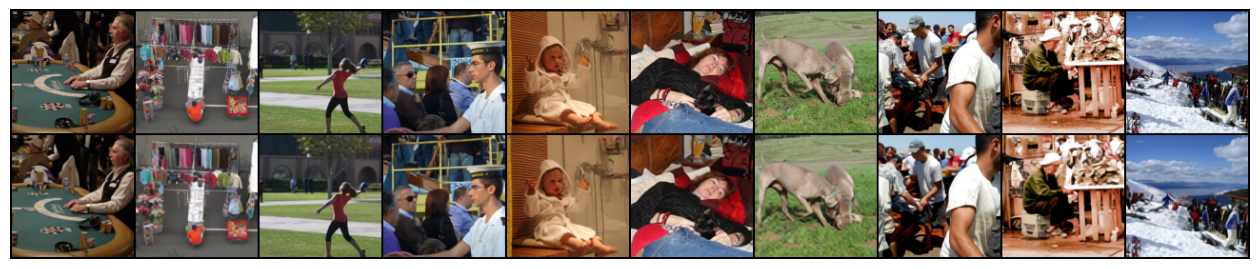

In [22]:
encoder_ema = VAEEncoder().to('cuda')
decoder_mae = VAEDecoder().to('cuda')
ckpt = torch.load('model_weights/best_vae.pt')
encoder_ema.load_state_dict(ckpt['encoder_ema'])
decoder_mae.load_state_dict(ckpt['decoder_ema'])
import matplotlib.pyplot as plt
def reconstruct(encoder, decoder, val_loader, device, n_images=8, save_path=None):
    encoder.eval()
    decoder.eval()
    x = next(iter(val_loader))[3: 3+n_images].to(device)
    with torch.no_grad():
        mu, logvar = encoder(x)
        z = reparameterize(mu, logvar)
        x_recon = decoder(z)

    orig = (x*0.5 + 0.5).clamp(0, 1)
    recon = (x_recon*0.5 + 0.5).clamp(0, 1)
    comparasion = torch.cat([orig, recon], dim=0)
    grid = torchvision.utils.make_grid(comparasion, nrow=n_images)
    plt.figure(figsize=(16, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.show()
    return orig, recon

orig, recon = reconstruct(encoder_ema, decoder_mae, val_loader, 'cuda', n_images=10)

In [8]:
def parse_flickr_captions(captions_file):
    captions_by_image = defaultdict(list)
    line_re = re.compile(r'^(\S+)#\d+\t(.+)$')
 
    with open(captions_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = line_re.match(line)
            if not m:
                continue
            filename, caption = m.group(1), m.group(2)
            captions_by_image[filename].append(caption)
 
    return dict(captions_by_image)

class ImageOnlyDataset(Dataset):
    def __init__(self, image_dir, filenames, image_size=128):
        self.image_dir = image_dir
        self.filenames = filenames
        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])
 
    def __len__(self):
        return len(self.filenames)
 
    def __getitem__(self, idx):
        filename = self.filenames[idx]
        img = Image.open(os.path.join(self.image_dir, filename)).convert('RGB')
        return filename, self.transform(img)


@torch.no_grad()
def cache_latents(image_dir, vae_checkpoint_path, output_dir, device,
                   image_size=128, batch_size=64):
    
    os.makedirs(output_dir, exist_ok=True)
 
    encoder = VAEEncoder(latent_channels=4).to(device)
    ckpt = torch.load(vae_checkpoint_path, map_location=device)
    encoder.load_state_dict(ckpt['encoder'])
    encoder.eval()
 
    filenames = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    dataset = ImageOnlyDataset(image_dir, filenames, image_size=image_size)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
 
    for filenames_batch, images in tqdm(loader, desc="caching latents"):
        images = images.to(device)
        mu, _ = encoder(images)  # (B, 4, H/4, W/4)
        for fname, latent in zip(filenames_batch, mu.cpu()):
            torch.save(latent, os.path.join(output_dir, f"{fname}.pt"))
 
    print(f"cached {len(filenames)} latents to {output_dir}")


def compute_latent_scale(latent_dir, output_path, sample_size=2000):
    files = [f for f in os.listdir(latent_dir) if f.endswith('.pt')]
    sample_files = files[:sample_size] if len(files) > sample_size else files
 
    all_latents = torch.stack([torch.load(os.path.join(latent_dir, f)) for f in sample_files])
    std = all_latents.std().item()
    scale = 1.0 / std
 
    with open(output_path, 'w') as f:
        json.dump({'std': std, 'scale_factor': scale, 'n_samples': len(sample_files)}, f, indent=2)
 
    print(f"latent std: {std:.4f}, scale_factor: {scale:.4f} (from {len(sample_files)} samples)")
   



In [9]:
class ClipTokenEmbedder(nn.Module):
    def __init__(self, model_name='ViT-B-32', pretrained='laion2b_s34b_b79k'):
        super().__init__()
        model, _, _ = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
        self.tokenizer = open_clip.get_tokenizer(model_name)
 
        self.token_embedding = model.token_embedding
        self.positional_embedding = model.positional_embedding
        self.transformer = model.transformer
        self.ln_final = model.ln_final
        self.attn_mask = model.attn_mask
        self.context_length = model.context_length
        self.width = model.transformer.width
 
        for p in self.parameters():
            p.requires_grad = False
        self.eval()
 
    @torch.no_grad()
    def forward(self, texts, device):
        tokens = self.tokenizer(texts).to(device) 
 
        x = self.token_embedding(tokens)                       
        x = x + self.positional_embedding.to(x.dtype)
        x = self.transformer(x, attn_mask=self.attn_mask.to(device))
        x = self.ln_final(x)                                  
 
        return x, tokens

@torch.no_grad()
def cache_text_embeddings(captions_by_image, output_dir, device=None,
                           model_name='ViT-B-32', pretrained='laion2b_s34b_b79k',
                           batch_size=128):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    os.makedirs(output_dir, exist_ok=True)
 
    embedder = ClipTokenEmbedder(model_name=model_name, pretrained=pretrained).to(device)
 
    flat = []
    for filename, captions in captions_by_image.items():
        for i, caption in enumerate(captions):
            flat.append((filename, i, caption))
 
    for start in tqdm(range(0, len(flat), batch_size), desc="caching text embeddings"):
        batch = flat[start:start + batch_size]
        texts = [b[2] for b in batch]
        embeddings, _ = embedder(texts, device) 
        
 
        embeddings = embeddings.cpu()

        for (filename, cap_idx, _), emb in zip(batch, embeddings):
            emb = emb.detach().cpu().clone()

            path = os.path.join(
                output_dir,
                f"{filename}__cap{cap_idx}.pt"
            )

            torch.save(emb, path)
 
    print(f"cached {len(flat)} text embeddings to {output_dir}")



In [5]:
import os
import csv
import json
import torch
from collections import defaultdict
from tqdm import tqdm

def parse_captions_csv(captions_file):
    captions_by_image = defaultdict(list)
    
    if not os.path.exists(captions_file):
        raise FileNotFoundError(f"Файл не найден: {captions_file}")
    
    with open(captions_file, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)

        try:
            header = next(reader)
            print(f"Заголовок: {header}")
        except StopIteration:
            print("⚠️ Файл пуст!")
            return {}
        
        if header != ['image', 'caption'] and header != ['image', 'caption']:
            print(f"⚠️ Заголовок '{header}' не соответствует ожидаемому 'image,caption'")
            f.seek(0)
            reader = csv.reader(f)
            f.seek(0)
            reader = csv.reader(f)
            first_row = next(reader)
            if first_row[0] == 'image' or first_row[0] == '1000092795.jpg':
                print(f"Пропускаем первую строку: {first_row}")
            else:
                f.seek(0)
                reader = csv.reader(f)
        
        for row in reader:
            if not row:
                continue
            if len(row) < 2:
                continue
            
            filename = row[0].strip()
            caption = row[1].strip()
            if caption.startswith('"') and caption.endswith('"'):
                caption = caption[1:-1]
            
            captions_by_image[filename].append(caption)
    
    return dict(captions_by_image)

try:
    captions = parse_captions_csv('data/captions.txt')
except FileNotFoundError as e:
    print(f"❌ {e}")
    exit(1)

print(f"✅ Распарсено {len(captions)} изображений")
print(f"✅ Всего подписей: {sum(len(v) for v in captions.values())}")

with open('captions.json', 'w', encoding='utf-8') as f:
    json.dump(captions, f, ensure_ascii=False, indent=2)

print("✅ Сохранено в captions.json")


Заголовок: ['image', 'caption']
✅ Распарсено 31783 изображений
✅ Всего подписей: 158915
✅ Сохранено в captions.json


In [25]:
import json

# 1️⃣ Загружаем словарь из JSON
with open('captions.json', 'r', encoding='utf-8') as f:
    captions = json.load(f)  # ← теперь это словарь

# 2️⃣ Передаем словарь
cache_text_embeddings(captions, 'cache/text_embeddings')

caching text embeddings: 100%|██████████| 1242/1242 [06:22<00:00,  3.25it/s]

cached 158915 text embeddings to cache/text_embeddings


In [10]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
 
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=device).float() / half_dim
        )
        args = t.float()[:, None] * freqs[None, :]
        embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            embedding = F.pad(embedding, (0, 1))
        return embedding

class TimeEmbeddingMLP(nn.Module):
    def __init__(self, dim, time_embed_dim):
        super().__init__()
        self.sinusoidal = SinusoidalTimeEmbedding(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )
 
    def forward(self, t):
        return self.mlp(self.sinusoidal(t))


class ResBlockTime(nn.Module):
    def __init__(self, in_ch, out_ch, time_embed_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
 
        self.time_proj = nn.Linear(time_embed_dim, out_ch)
 
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
 
        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()
 
    def forward(self, x, time_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(time_emb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class CrossAttentionBlock(nn.Module):
    def __init__(self, channels, context_dim, num_heads=8):
        super().__init__()
        self.norm_in = nn.GroupNorm(8, channels)
        self.proj_in = nn.Conv2d(channels, channels, kernel_size=1)
 
        self.num_heads = num_heads
        self.head_dim = channels // num_heads
 
        self.norm_self = nn.LayerNorm(channels)
        self.self_attn = nn.MultiheadAttention(channels, num_heads, batch_first=True)
 
        self.norm_cross = nn.LayerNorm(channels)
        self.to_q = nn.Linear(channels, channels)
        self.to_k = nn.Linear(context_dim, channels)
        self.to_v = nn.Linear(context_dim, channels)
        self.cross_out = nn.Linear(channels, channels)
 
        self.norm_ff = nn.LayerNorm(channels)
        self.ff = nn.Sequential(
            nn.Linear(channels, channels * 4),
            nn.GELU(),
            nn.Linear(channels * 4, channels),
        )
 
        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1)
 
    def forward(self, x, context):
        b, c, h, w = x.shape
        residual = x
 
        x = self.proj_in(self.norm_in(x))
        x = x.reshape(b, c, h * w).permute(0, 2, 1)
 
        x = x + self.self_attn(self.norm_self(x), self.norm_self(x), self.norm_self(x))[0]
 
        x_norm = self.norm_cross(x)
        q = self.to_q(x_norm)
        k = self.to_k(context)
        v = self.to_v(context)
 
        q = q.reshape(b, -1, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.reshape(b, -1, self.num_heads, self.head_dim).transpose(1, 2)  
        v = v.reshape(b, -1, self.num_heads, self.head_dim).transpose(1, 2)
 
        attn = torch.softmax(q @ k.transpose(-1, -2) / math.sqrt(self.head_dim), dim=-1)
        out = attn @ v 
        out = out.transpose(1, 2).reshape(b, h * w, c)
        x = x + self.cross_out(out)
 
        x = x + self.ff(self.norm_ff(x))
 
        x = x.permute(0, 2, 1).reshape(b, c, h, w)
        return self.proj_out(x) + residual



In [11]:
class UNet(nn.Module):
    def __init__(self, in_channels=4, base_ch=128, context_dim=512,
                 num_res_blocks=2, num_heads=8):
        super().__init__()
        time_embed_dim = base_ch * 4
        self.time_embed = TimeEmbeddingMLP(base_ch, time_embed_dim)
 
        self.in_conv = nn.Conv2d(in_channels, base_ch, kernel_size=3, padding=1)
 
        self.down0 = nn.ModuleList([
            ResBlockTime(base_ch, base_ch, time_embed_dim) for _ in range(num_res_blocks)
        ])
        self.downsample0 = Downsample(base_ch)
 
        ch1 = base_ch * 2
        self.down1_res = nn.ModuleList([
            ResBlockTime(base_ch if i == 0 else ch1, ch1, time_embed_dim) for i in range(num_res_blocks)
        ])
        self.down1_attn = nn.ModuleList([
            CrossAttentionBlock(ch1, context_dim, num_heads) for _ in range(num_res_blocks)
        ])
        self.downsample1 = Downsample(ch1)
 
        ch2 = base_ch * 4
        self.down2_res = nn.ModuleList([
            ResBlockTime(ch1 if i == 0 else ch2, ch2, time_embed_dim) for i in range(num_res_blocks)
        ])
        self.down2_attn = nn.ModuleList([
            CrossAttentionBlock(ch2, context_dim, num_heads) for _ in range(num_res_blocks)
        ])
 
        self.mid_res1 = ResBlockTime(ch2, ch2, time_embed_dim)
        self.mid_attn = CrossAttentionBlock(ch2, context_dim, num_heads)
        self.mid_res2 = ResBlockTime(ch2, ch2, time_embed_dim)
 
        self.up2_res = nn.ModuleList([
            ResBlockTime(ch2 * 2, ch2, time_embed_dim) for _ in range(num_res_blocks)
        ])
        self.up2_attn = nn.ModuleList([
            CrossAttentionBlock(ch2, context_dim, num_heads) for _ in range(num_res_blocks)
        ])
        self.upsample2 = Upsample(ch2)
        self.up2_to_ch1 = nn.Conv2d(ch2, ch1, kernel_size=1)
 
        self.up1_res = nn.ModuleList([
            ResBlockTime(ch1 * 2, ch1, time_embed_dim) for _ in range(num_res_blocks)
        ])
        self.up1_attn = nn.ModuleList([
            CrossAttentionBlock(ch1, context_dim, num_heads) for _ in range(num_res_blocks)
        ])
        self.upsample1 = Upsample(ch1)
        self.up1_to_ch0 = nn.Conv2d(ch1, base_ch, kernel_size=1)
 
        self.up0_res = nn.ModuleList([
            ResBlockTime(base_ch * 2, base_ch, time_embed_dim) for _ in range(num_res_blocks)
        ])
 
        self.norm_out = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, in_channels, kernel_size=3, padding=1)
 
    def forward(self, x, timesteps, context):
        
        time_emb = self.time_embed(timesteps)
 
        x = self.in_conv(x)
 
        skips = []
 
        for block in self.down0:
            x = block(x, time_emb)
            skips.append(x)
        x = self.downsample0(x)
 
        for res, attn in zip(self.down1_res, self.down1_attn):
            x = res(x, time_emb)
            x = attn(x, context)
            skips.append(x)
        x = self.downsample1(x)
 
        for res, attn in zip(self.down2_res, self.down2_attn):
            x = res(x, time_emb)
            x = attn(x, context)
            skips.append(x)
 
        x = self.mid_res1(x, time_emb)
        x = self.mid_attn(x, context)
        x = self.mid_res2(x, time_emb)
 
       
        for res, attn in zip(self.up2_res, self.up2_attn):
            x = torch.cat([x, skips.pop()], dim=1)
            x = res(x, time_emb)
            x = attn(x, context)
        x = self.up2_to_ch1(self.upsample2(x))
 
        for res, attn in zip(self.up1_res, self.up1_attn):
            x = torch.cat([x, skips.pop()], dim=1)
            x = res(x, time_emb)
            x = attn(x, context)
        x = self.up1_to_ch0(self.upsample1(x))
 
        for res in self.up0_res:
            x = torch.cat([x, skips.pop()], dim=1)
            x = res(x, time_emb)
 
        x = F.silu(self.norm_out(x))
        return self.out_conv(x)


In [12]:
class GaussianDiffusion:
 
    def __init__(self, num_timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.num_timesteps = num_timesteps
 
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
 
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
 
    def to(self, device):
        self.betas = self.betas.to(device)
        self.alphas = self.alphas.to(device)
        self.alphas_cumprod = self.alphas_cumprod.to(device)
        self.sqrt_alphas_cumprod = self.sqrt_alphas_cumprod.to(device)
        self.sqrt_one_minus_alphas_cumprod = self.sqrt_one_minus_alphas_cumprod.to(device)
        return self
 
    def q_sample(self, x0, t, noise=None, generator=None):
        if noise is None:
            if generator is None:
                noise = torch.randn(x0.shape, device = x0.device, dtype=x0.dtype, generator=generator)
            else:
                noise = torch.randn_like(x0)
 
        sqrt_ac = self.sqrt_alphas_cumprod[t].reshape(-1, 1, 1, 1)
        sqrt_1m_ac = self.sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1, 1)
 
        x_t = sqrt_ac * x0 + sqrt_1m_ac * noise
        return x_t, noise
 
    def sample_timesteps(self, batch_size, device, generator=None):
        return torch.randint(0, self.num_timesteps, (batch_size,), device=device, generator=generator)


    def min_snr_weights(self, t, gamma=5.0):
        alpha_cumprod_t = self.alphas_cumprod[t]
        snr = alpha_cumprod_t / (1.0 - alpha_cumprod_t)
        weight = torch.clamp(snr, max=gamma) / snr
        return weight


In [13]:
class LatentTextDataset(Dataset):
    def __init__(self, latent_dir, text_emb_dir, scale_factor, determistic=False):
        self.latent_dir = latent_dir
        self.text_emb_dir = text_emb_dir
        self.scale_factor = scale_factor
        self.determistic = determistic
 
        latent_files = [f for f in os.listdir(latent_dir) if f.endswith('.pt')]
        image_ids = [f[:-3] for f in latent_files]
 
        text_files = os.listdir(text_emb_dir)
        by_image = defaultdict(list)
        for f in text_files:
            if '__cap' not in f:
                continue
            image_id = f.split('__cap')[0]
            by_image[image_id].append(f)
 
        self.image_ids = [img_id for img_id in image_ids if img_id in by_image]
        self.captions_by_image = {img_id: by_image[img_id] for img_id in self.image_ids}
 
        if len(self.image_ids) == 0:
            raise ValueError(
                "No images with both a cached latent and a cached caption embedding were found. "
            )
 
    def __len__(self):
        return len(self.image_ids)
 
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
 
        latent = torch.load(os.path.join(self.latent_dir, f"{image_id}.pt"))
        latent = latent * self.scale_factor
        caption_files = self.captions_by_image[image_id]
        if self.determistic:
            caption_file = caption_files[0]
        else:
            caption_file = random.choice(caption_files)
        text_emb = torch.load(os.path.join(self.text_emb_dir, caption_file))
 
        return latent, text_emb


@torch.no_grad()
def compute_null_embedding(device, model_name='ViT-B-32', pretrained='laion2b_s34b_b79k'):
    embedder = ClipTokenEmbedder(model_name=model_name, pretrained=pretrained).to(device)
    null_emb, _ = embedder([""], device)
    return null_emb[0].detach().clone()

def apply_cfg_dropout(context, null_embedding, dropout_prob):
    b = context.shape[0]
    mask = (torch.rand(b, device=context.device) < dropout_prob)
    mask = mask[:, None, None]
    null_expanded = null_embedding.unsqueeze(0).expand_as(context)
    return torch.where(mask, null_expanded, context)


In [ ]:
def ddim_sample(unet, diffusion, context, null_embedding, shape, device, num_inference_steps=50, guidance_scale=7.5, seed=None):
    if seed is not None:
        generator = torch.Generator(device=device).manual_seed(seed)
        x = torch.randn(shape, device=device, generator=generator)
    else:
        x = torch.randn(shape, device=device)
    
    b = shape[0]
    num_train_timesteps = diffusion.num_timesteps
    timesteps = torch.linspace(num_train_timesteps - 1, 0, num_inference_steps, device=device).round().long()
    null_batch = null_embedding.unsqueeze(0).expand(b, -1, -1).to(device)

    for i in range(len(timesteps)):
        t = timesteps[i]
        t_batch = torch.full((b, ), t, device=device, dtype=torch.long)
        eps_uncond = unet(x, t_batch, null_batch)
        eps_cond = unet(x, t_batch, context)
        eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
        alpha_t = diffusion.alphas_cumprod[t]
        if i + 1 < len(timesteps):
            alpha_prev = diffusion.alphas_cumprod[timesteps[i+1]]
        else:
            alpha_prev = torch.tensor(1.0, device=device)
        x0_pred = (x - torch.sqrt(1 - alpha_t) * eps) / torch.sqrt(alpha_t)
        x = torch.sqrt(alpha_prev) * x0_pred + torch.sqrt(1 - alpha_prev) * eps
    return x

@torch.no_grad()
def sample_and_decode(unet, decoder, diffusion, context, null_embedding, scale_factor, device, latent_shape=(4, 32, 32), num_inference_steps=50, guidance_scale=7.5, seed=None):
    b = context.shape[0]
    shape = (b, *latent_shape)
    latents = ddim_sample(
        unet, diffusion, context, null_embedding, shape, device,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        seed=seed
    )
    latents /= scale_factor
    images = decoder(latents)
    images = (images.clamp(-1, 1) + 1) / 2
    return images


def pick_random_val_captions(val_subset, text_emb_dir, captions_index, n=5, seed=None):
    rng = random.Random(seed)
    base_dataset = val_subset.dataset
    val_image_ids = [base_dataset.image_ids[i] for i in val_subset.indices]
    chosen = []
    candidates = list(val_image_ids)
    rng.shuffle(candidates)
    for image_id in candidates:
        if len(chosen) >= n:
            break
        caption_files = base_dataset.captions_by_image[image_id]
        cap_file = rng.choice(caption_files)
        if cap_file not in captions_index:
            continue
        chosen.append((os.path.join(text_emb_dir, cap_file), captions_index[cap_file]))
    return chosen


@torch.no_grad()
def log_generated_samples(unet, ema_unet, decoder, diffusion, val_subset,
text_emb_dir, captions_index, null_embedding, scale_factor, device, writer,
epoch, n_samples, num_inference_steps=50, guidance_scale=7.5, fixed_seed=0, clip_scorer=None):
    samples = pick_random_val_captions(val_subset, text_emb_dir, captions_index, n=n_samples, seed=fixed_seed)
    if not samples:
         return

    contexts = torch.stack([torch.load(path) for path, _ in samples]).to(device)
    captions_text = [text for _, text in samples]
    raw_state = {k: v.clone() for k, v in unet.state_dict().items()}
    unet.load_state_dict(ema_unet.shadow)
    unet.eval()

    images = sample_and_decode(unet, decoder, diffusion, contexts, null_embedding, scale_factor,
    device=device, num_inference_steps=num_inference_steps, guidance_scale=guidance_scale, seed=fixed_seed)
    unet.load_state_dict(raw_state)
    unet.train()

    for i, (img, caption) in enumerate(zip(images, captions_text)):
        writer.add_image(f'samples/{i}', img, epoch)
        writer.add_text(f'samples/{i}_caption', caption, epoch)
    
    grid = make_grid(images, nrow=n_samples, padding=2)
    writer.add_image('samples/grid', grid, epoch)

    if clip_scorer is not None:
        scores = clip_scorer.clip_score(images, captions_text, device)
        writer.add_scalar('samples/clip_score_mean', scores.mean().item(), epoch)
        for i, (score, caption) in enumerate(zip(scores.tolist(), captions_text)):
            writer.add_scalar(f'samples/clip_score_{i}', score, epoch)
        print(f"epoch {epoch} CLIPScore (mean over {n_samples} prompts): {scores.mean().item():.3f}")
        return scores.mean().item()
 
    return None


@torch.no_grad()
def validate(unet, diffusion, val_loader, device, val_seed=123):
    unet.eval()
    total_loss = 0.0
    n_batches = 0
    generator = torch.Generator(device=device).manual_seed(val_seed)
 
    for latents, contexts in val_loader:
        latents = latents.to(device)
        contexts = contexts.to(device)
 
        t = diffusion.sample_timesteps(latents.shape[0], device, generator=generator)
        x_t, noise = diffusion.q_sample(latents, t, generator=generator)
        pred_noise = unet(x_t, t, contexts)
        loss = F.mse_loss(pred_noise, noise)
 
        total_loss += loss.item()
        n_batches += 1
 
    unet.train()
    return total_loss / n_batches

@torch.no_grad()
def validate_with_ema(unet, ema_unet, diffusion, val_loader, device):
    raw_state = {k: v.clone() for k, v in unet.state_dict().items()}
    unet.load_state_dict(ema_unet.shadow)
    ema_loss = validate(unet, diffusion, val_loader, device)
    unet.load_state_dict(raw_state)
    return ema_loss



In [ ]:

with open('captions.json', 'r') as f:
    data = json.load(f)

new_data = {}
for filename, captions in data.items():
    for idx, caption in enumerate(captions):
        # Ключ: имя_файла__cap{номер}
        key = f"{filename}__cap{idx}.pt"
        new_data[key] = caption

# Сохраняем в новый JSON
with open('captions_flat.json', 'w', encoding='utf-8') as f:
    json.dump(new_data, f, ensure_ascii=False, indent=2)

In [ ]:

def compute_loss_min_snr(unet, diffusion, latents, contexts, null_embedding,
                          cfg_dropout_prob, gamma, device):
    contexts = apply_cfg_dropout(contexts, null_embedding, cfg_dropout_prob)
    t = diffusion.sample_timesteps(latents.shape[0], device)
    x_t, noise = diffusion.q_sample(latents, t)
 
    pred_noise = unet(x_t, t, contexts)
    per_sample_mse = F.mse_loss(pred_noise, noise, reduction='none').mean(dim=[1, 2, 3])
 
    weights = diffusion.min_snr_weights(t, gamma=gamma)
    return (weights * per_sample_mse).mean()

class ClipScorer(nn.Module):
 
    def __init__(self, model_name='ViT-B-32', pretrained='laion2b_s34b_b79k'):
        super().__init__()
        model, _, _ = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
        self.model = model
        self.tokenizer = open_clip.get_tokenizer(model_name)
 
        image_size = model.visual.image_size
        self.image_size = image_size[0] if isinstance(image_size, (tuple, list)) else image_size
 
        self.register_buffer('mean', torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1))
 
        for p in self.model.parameters():
            p.requires_grad = False
        self.eval()
 
    @torch.no_grad()
    def encode_images(self, images):
        images = F.interpolate(images, size=(self.image_size, self.image_size),
                                mode='bicubic', align_corners=False)
        images = (images - self.mean) / self.std
        features = self.model.encode_image(images)
        return F.normalize(features, dim=-1)
 
    @torch.no_grad()
    def encode_texts(self, texts, device):
        tokens = self.tokenizer(texts).to(device)
        features = self.model.encode_text(tokens)
        return F.normalize(features, dim=-1)
 
    @torch.no_grad()
    def clip_score(self, images, texts, device, w=2.5):
        image_feats = self.encode_images(images)
        text_feats = self.encode_texts(texts, device)
        cos_sim = (image_feats * text_feats).sum(dim=-1)
        return w * torch.clamp(cos_sim, min=0)


In [ ]:
def train(
    latent_dir,
    text_emb_dir,
    scale_file,
    output_dir='checkpoints_diffusion_minsnr_start',
    batch_size=32,
    num_epochs=200,
    lr=1e-4,
    num_timesteps=1000,
    cfg_dropout_prob=0.1,
    val_fraction=0.05,
    early_stopping_patience=30,
    ema_decay=0.999,
    base_ch=128,
    num_res_blocks=2,
    seed=42,
    sample_every_n_epochs=5,
    sample_n_images=5,
    sample_inference_steps=50,
    sample_guidance_scale=7.5,
    min_snr_gamma=5.0
):
    os.makedirs(output_dir, exist_ok=True)
    random.seed(seed)
    torch.manual_seed(seed)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    writer = SummaryWriter('RUNS_diffusion_minsnr_start')
 
    with open(scale_file, 'r') as f:
        scale_factor = json.load(f)['scale_factor']
 
    full_dataset = LatentTextDataset(latent_dir, text_emb_dir, scale_factor, determistic=False)
    n_val = max(1, int(len(full_dataset) * val_fraction))
    n_train = len(full_dataset) - n_val
    train_subset, val_subset = random_split(
        full_dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )
    val_dataset_determistic = copy.copy(full_dataset)
    val_dataset_determistic.determistic = True
    val_subset.dataset = val_dataset_determistic
 
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,
                               num_workers=0, drop_last=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False,
                             num_workers=0)
 
    print(f"train images: {n_train}, val images: {n_val}")
 
    
    with open('captions_flat.json', 'r', encoding='utf-8') as f:
        captions_index = json.load(f)
    unet = UNet(in_channels=4, base_ch=base_ch, context_dim=512,
                num_res_blocks=num_res_blocks).to(device)
    diffusion = GaussianDiffusion(num_timesteps=num_timesteps, device=device)
    null_embedding = compute_null_embedding(device)
 
    decoder = VAEDecoder(latent_channels=4).to(device)
    vae_ckpt = torch.load('model_weights/best_vae.pt', map_location=device)
    decoder.load_state_dict(vae_ckpt['decoder'])
    decoder.eval()
    for p in decoder.parameters():
        p.requires_grad = False

    ema_unet = EMA(unet, decay=ema_decay)
    optimizer = torch.optim.AdamW(unet.parameters(), lr=lr)

    total_steps = num_epochs * len(train_loader)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=total_steps, eta_min=lr*0.01
    )
 
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    global_step = 0
 
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = 0.0
        n_batches = 0
 
        for latents, contexts in train_loader:
            latents = latents.to(device)
            contexts = contexts.to(device)
            contexts = apply_cfg_dropout(contexts, null_embedding, cfg_dropout_prob)
 
            t = diffusion.sample_timesteps(latents.shape[0], device)
            x_t, noise = diffusion.q_sample(latents, t)
 
            optimizer.zero_grad()
            pred_noise = unet(x_t, t, contexts)
            loss = compute_loss_min_snr(
                unet, diffusion, latents, contexts, null_embedding,
                cfg_dropout_prob, min_snr_gamma, device,
            )
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
 
            ema_unet.update(unet)
 
            epoch_loss += loss.item()
            n_batches += 1
            global_step += 1
 
        train_avg_loss = epoch_loss / n_batches
        print(f"epoch {epoch} train_loss={train_avg_loss:.4f}")
        writer.add_scalar('train/mse_loss', train_avg_loss, epoch)
 
        val_loss_raw = validate(unet, diffusion, val_loader, device)
        val_loss_ema = validate_with_ema(unet, ema_unet, diffusion, val_loader, device)
        print(f"[val] epoch {epoch} raw={val_loss_raw:.4f} ema={val_loss_ema:.4f}")
        writer.add_scalar('val/mse_loss_raw', val_loss_raw, epoch)
        writer.add_scalar('val/mse_loss_ema', val_loss_ema, epoch)
 
        if epoch % sample_every_n_epochs == 0:
            log_generated_samples(
                unet, ema_unet, decoder, diffusion, val_subset,
                'cache/text_embeddings', captions_index, null_embedding,
                scale_factor, device, writer, epoch, n_samples=sample_n_images,
                num_inference_steps=sample_inference_steps,
                guidance_scale=sample_guidance_scale
            )

        if val_loss_ema < best_val_loss:
            best_val_loss = val_loss_ema
            epochs_without_improvement = 0
            torch.save({
                'unet': ema_unet.state_dict(),
                'unet_raw': unet.state_dict(),
                'null_embedding': null_embedding.cpu(),
                'scale_factor': scale_factor,
                'num_timesteps': num_timesteps,
                'epoch': epoch,
                'val_loss_ema': best_val_loss,
            }, os.path.join(output_dir, 'best_unet.pt'))
            print(f"  -> new best EMA val loss {best_val_loss:.4f}, checkpoint saved")
        else:
            epochs_without_improvement += 1
            print(f"  -> no improvement ({epochs_without_improvement}/{early_stopping_patience})")
            if epochs_without_improvement >= early_stopping_patience:
                print(f"early stopping at epoch {epoch} "
                      f"(remember: diffusion val loss is a noisy proxy -- if samples still "
                      f"look like they're improving, consider raising patience)")
                break
 
    writer.close()
    print("training finished, best EMA val loss:", best_val_loss)


In [ ]:
train(
    latent_dir='cache/latents',
    text_emb_dir='cache/text_embeddings',
    scale_file='cache/latent_scale.json'
)

train images: 30194, val images: 1589


  0%|          | 0/200 [00:00<?, ?it/s]

epoch 0 train_loss=0.1530
[val] epoch 0 raw=0.2095 ema=0.2549


  0%|          | 1/200 [08:00<26:34:58, 480.90s/it]

  -> new best EMA val loss 0.2549, checkpoint saved
epoch 1 train_loss=0.1284
[val] epoch 1 raw=0.2003 ema=0.2104


...

[val] epoch 172 raw=0.1716 ema=0.1717
  -> no improvement (7/30)
epoch 173 train_loss=0.1047
[val] epoch 173 raw=0.1716 ema=0.1711


 87%|████████▋ | 174/200 [21:59:36<3:20:42, 463.18s/it]

  -> new best EMA val loss 0.1711, checkpoint saved
epoch 174 train_loss=0.1044


 88%|████████▊ | 175/200 [22:07:35<3:14:54, 467.78s/it]

[val] epoch 174 raw=0.1713 ema=0.1717
  -> no improvement (1/30)


Using device: cuda
✅ Все модели загружены!

📂 Загружаем индексы подписей...
✅ Загружено 158915 подписей
📂 Создаем валидационный датасет...
✅ Валидационный датасет: 20 примеров

🎨 Генерируем изображения...

▶️ Генерация по своим промптам:


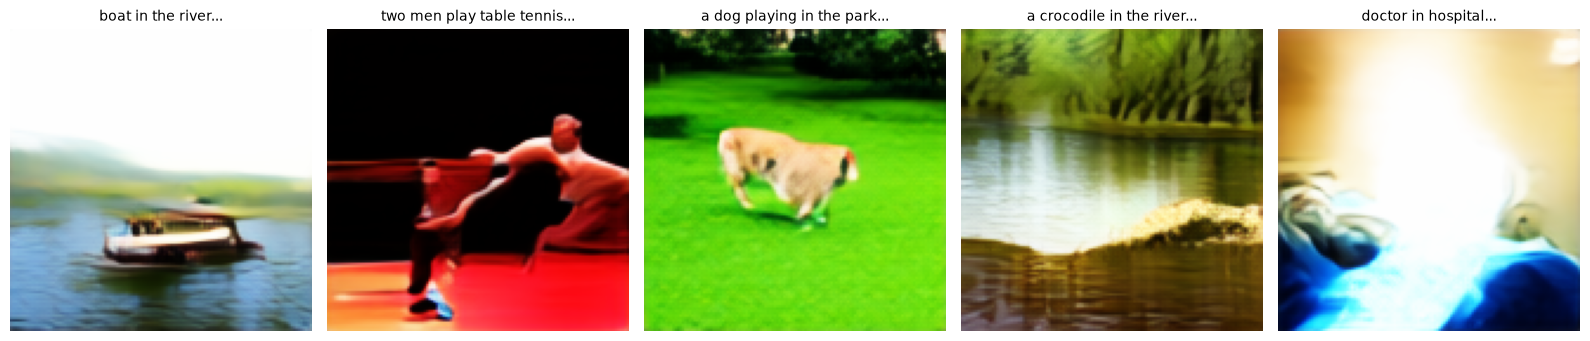


▶️ Генерация по случайным подписям из датасета:
❌ Не найдено подписей для генерации!

✅ Генерация завершена!


In [27]:
import matplotlib.pyplot as plt
import torch
from torchvision.utils import make_grid
import numpy as np
import json
import os

def get_null_embedding(device):
    embedder = ClipTokenEmbedder().to(device)
    embedder.eval()
    with torch.no_grad():
        null_emb, _ = embedder([""], device)
    return null_emb[0].detach().clone()


# ============= НАСТРОЙКА =============
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# ============= ЗАГРУЗКА МОДЕЛЕЙ =============

# 1. Загружаем чекпоинт диффузионной модели
ckpt_path = 'checkpoints_diffusion_minsnr/best_unet.pt'
if not os.path.exists(ckpt_path):
    print(f"❌ Чекпоинт не найден: {ckpt_path}")
    print("   Сначала обучите модель или проверьте путь!")
    raise FileNotFoundError(ckpt_path)

ckpt = torch.load(ckpt_path, map_location=device)

# 2. Инициализируем UNet
unet = UNet(in_channels=4, base_ch=128, context_dim=512).to(device)
unet.load_state_dict(ckpt['unet_raw'])  # или ckpt['unet'] если там EMA

# 3. Создаем EMA-объект и загружаем EMA-веса
ema_unet = EMA(unet)  # создаем объект EMA
ema_unet.shadow = ckpt['unet_ema']  # загружаем EMA-веса из чекпоинта

# 4. Инициализируем диффузию
diffusion = GaussianDiffusion(
    num_timesteps=ckpt['num_timesteps'], 
    device=device
)

# 5. Загружаем декодер VAE
decoder = VAEDecoder(latent_channels=4).to(device)
vae_ckpt = torch.load('model_weights/best_vae.pt', map_location=device)
decoder.load_state_dict(vae_ckpt['decoder'])
decoder.eval()

# 6. Загружаем null_embedding и scale_factor
null_embedding = get_null_embedding(device)
scale_factor = ckpt['scale_factor']

print("✅ Все модели загружены!")

# ============= ФУНКЦИИ ДЛЯ ГЕНЕРАЦИИ =============

@torch.no_grad()
def generate_by_prompts(
    prompts,  # список строк
    unet,
    ema_unet,
    decoder,
    diffusion,
    null_embedding,
    scale_factor,
    device,
    num_inference_steps=50,
    guidance_scale=12,
    seed=42,
    figsize=(16, 10)
):
    """
    Генерирует изображения по заданным текстовым промптам.
    """
    # Получаем эмбеддинги для промптов
    embedder = ClipTokenEmbedder().to(device)
    embedder.eval()
    
    with torch.no_grad():
        contexts, _ = embedder(prompts, device)  # (B, seq_len, 512)
    
    # Загружаем EMA-веса
    raw_state = {k: v.clone() for k, v in unet.state_dict().items()}
    unet.load_state_dict(ema_unet.state_dict())
    unet.eval()
    
    # Генерируем
    images = sample_and_decode(
        unet, decoder, diffusion, contexts, null_embedding, scale_factor,
        device=device,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        seed=seed
    )
    
    # Восстанавливаем исходное состояние
    unet.load_state_dict(raw_state)
    unet.train()
    
    # Визуализация
    n_samples = len(prompts)
    fig, axes = plt.subplots(1, n_samples, figsize=figsize)
    if n_samples == 1:
        axes = [axes]
    
    for i, (img, prompt) in enumerate(zip(images, prompts)):
        img_np = img.cpu().permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)
        
        axes[i].imshow(img_np)
        axes[i].set_title(f"{prompt[:50]}...", fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return images


def generate_and_plot_grid(
    unet,
    ema_unet,
    decoder,
    diffusion,
    val_subset,
    text_emb_dir,
    captions_index,
    null_embedding,
    scale_factor,
    device,
    n_samples=8,
    num_inference_steps=50,
    guidance_scale=12,
    seed=42,
    figsize=(16, 10)
):
    """
    Генерирует изображения по случайным подписям из валидационного набора.
    """
    # Выбираем случайные подписи
    samples = pick_random_val_captions(
        val_subset, 
        text_emb_dir, 
        captions_index, 
        n=n_samples, 
        seed=seed
    )
    
    if not samples:
        print("❌ Не найдено подписей для генерации!")
        return None, None
    
    # Загружаем эмбеддинги
    contexts = torch.stack([torch.load(path) for path, _ in samples]).to(device)
    captions_text = [text for _, text in samples]
    
    # Загружаем EMA-веса
    raw_state = {k: v.clone() for k, v in unet.state_dict().items()}
    unet.load_state_dict(ema_unet.state_dict())
    unet.eval()
    
    # Генерируем
    images = sample_and_decode(
        unet, decoder, diffusion, contexts, null_embedding, scale_factor,
        device=device,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        seed=seed
    )
    
    # Восстанавливаем состояние
    unet.load_state_dict(raw_state)
    unet.train()
    
    # Визуализация сеткой
    grid = make_grid(images, nrow=n_samples, padding=10)
    grid_np = grid.cpu().permute(1, 2, 0).numpy()
    grid_np = np.clip(grid_np, 0, 1)
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(grid_np)
    ax.axis('off')
    
    # Добавляем подписи под каждым изображением
    h, w = grid_np.shape[0], grid_np.shape[1]
    img_width = w // n_samples
    y_pos = h - 15
    
    for i, caption in enumerate(captions_text):
        x_pos = i * img_width + img_width // 2
        ax.text(
            x_pos, y_pos, 
            f"{caption[:40]}...", 
            ha='center', va='bottom',
            fontsize=8, color='white',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.7)
        )
    
    plt.tight_layout()
    plt.show()
    
    return images, captions_text

# ============= ПОДГОТОВКА ДАННЫХ ДЛЯ ВАЛИДАЦИИ =============

print("\n📂 Загружаем индексы подписей...")
with open('captions_flat.json', 'r', encoding='utf-8') as f:
    captions_index = json.load(f)

print(f"✅ Загружено {len(captions_index)} подписей")

# Создаем валидационный датасет (если есть файлы)
latent_dir = 'cache/latents'
text_emb_dir = 'cache/text_embeddings'

if os.path.exists(latent_dir) and os.path.exists(text_emb_dir):
    print("📂 Создаем валидационный датасет...")
    full_dataset = LatentTextDataset(
        latent_dir, 
        text_emb_dir, 
        scale_factor, 
        determistic=True
    )
    # Берем первые 20 для быстрого теста
    val_subset = Subset(full_dataset, range(min(20, len(full_dataset))))
    print(f"✅ Валидационный датасет: {len(val_subset)} примеров")
else:
    print("⚠️ Папки с кешами не найдены!")
    print("   Сначала запустите кеширование данных.")
    val_subset = None

# ============= ГЕНЕРАЦИЯ =============

print("\n🎨 Генерируем изображения...\n")

# ВАРИАНТ 1: Свои промпты
prompts = [
    "boat in the river",
    "two men play table tennis",
    "a dog playing in the park",
    "a crocodile in the river",
    "doctor in hospital",
]

print("▶️ Генерация по своим промптам:")
images1 = generate_by_prompts(
    prompts=prompts,
    unet=unet,
    ema_unet=ema_unet,
    decoder=decoder,
    diffusion=diffusion,
    null_embedding=null_embedding,
    scale_factor=scale_factor,
    device=device,
    num_inference_steps=30,  # меньше шагов для скорости
    guidance_scale=12,
    seed=42
)

# ВАРИАНТ 2: Случайные подписи из датасета (если есть данные)
if val_subset is not None:
    print("\n▶️ Генерация по случайным подписям из датасета:")
    images2, captions2 = generate_and_plot_grid(
        unet=unet,
        ema_unet=ema_unet,
        decoder=decoder,
        diffusion=diffusion,
        val_subset=val_subset,
        text_emb_dir=text_emb_dir,
        captions_index=captions_index,
        null_embedding=null_embedding,
        scale_factor=scale_factor,
        device=device,
        n_samples=6,
        num_inference_steps=100,
        guidance_scale=10,
        seed=42
    )

print("\n✅ Генерация завершена!")

In [28]:
@torch.no_grad()
def embed_prompts(prompts, device, model_name='ViT-B-32', pretrained='laion2b_s34b_b79k'):
    """Embeds arbitrary new prompts (not necessarily in the cache) with a
    live CLIP model -- fine here since this is a one-off analysis script,
    not the training loop."""
    embedder = ClipTokenEmbedder(model_name=model_name, pretrained=pretrained).to(device)
    embeddings, _ = embedder(prompts, device)
    return embeddings  # (n_prompts, 77, 512)
 
 
@torch.no_grad()
def guidance_scale_sweep(
    prompts,
    guidance_scales,
    diffusion_checkpoint_path,
    vae_checkpoint_path,
    output_path='./guidance_scale_sweep_2.png',
    base_ch=128,        # must match the base_ch used in train_diffusion.py
    num_res_blocks=2,   # must match num_res_blocks used in train_diffusion.py
    num_inference_steps=50,
    seed=0,
    device=None,
):
    """
    Generates every (prompt, guidance_scale) combination and lays them out
    as a labeled grid: rows = prompts, columns = guidance_scale values.
 
    The SAME seed is reused across every guidance_scale for a given prompt,
    so within a row the only thing that changes left-to-right is the
    guidance strength -- not the starting noise. Without that, differences
    between columns could just be "different random draw" rather than a
    real guidance-scale effect.
    """
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
 
    diff_ckpt = torch.load(diffusion_checkpoint_path, map_location=device)
    unet = UNet(in_channels=4, base_ch=base_ch, context_dim=512, num_res_blocks=num_res_blocks).to(device)
    unet.load_state_dict(diff_ckpt['unet'])  # EMA weights (see train_diffusion.py checkpoint format)
    unet.eval()
 
    null_embedding =  get_null_embedding(device)
    scale_factor = diff_ckpt['scale_factor']
    num_timesteps = diff_ckpt['num_timesteps']
    diffusion = GaussianDiffusion(num_timesteps=num_timesteps, device=device)
 
    decoder = VAEDecoder(latent_channels=4).to(device)
    vae_ckpt = torch.load(vae_checkpoint_path, map_location=device)
    decoder.load_state_dict(vae_ckpt['decoder'])  # EMA weights (see train_vae.py checkpoint format)
    decoder.eval()
 
    contexts = embed_prompts(prompts, device)  # (n_prompts, 77, 512)
 
    all_images = {}  # (prompt_idx, scale) -> (3, H, W) tensor in [0, 1]
    for scale in guidance_scales:
        shape = (len(prompts), 4, 32, 32)
        latents = ddim_sample(unet, diffusion, contexts, null_embedding, shape, device,
                               num_inference_steps=num_inference_steps,
                               guidance_scale=scale, seed=seed)
        latents = latents / scale_factor
        images = decoder(latents)
        images = (images.clamp(-1, 1) + 1) / 2
        for i in range(len(prompts)):
            all_images[(i, scale)] = images[i].cpu()
 
    n_rows, n_cols = len(prompts), len(guidance_scales)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.4 * n_rows))
    axes = axes.reshape(n_rows, n_cols)  # normalize shape for the n_rows==1 / n_cols==1 edge cases
 
    for i, prompt in enumerate(prompts):
        for j, scale in enumerate(guidance_scales):
            img = all_images[(i, scale)].permute(1, 2, 0).numpy()
            ax = axes[i, j]
            ax.imshow(img)
            ax.set_xticks([])
            ax.set_yticks([])
            if i == 0:
                ax.set_title(f"scale={scale}", fontsize=10)
            if j == 0:
                ax.set_ylabel(prompt, fontsize=8, rotation=0, ha='right', va='center')
 
    plt.tight_layout()
    out_dir = os.path.dirname(output_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"saved sweep grid to {output_path}")
    return output_path


In [29]:
guidance_scales = [7.5, 9, 10, 12, 14]

guidance_scale_sweep(
    prompts=prompts,
    guidance_scales=guidance_scales,
    diffusion_checkpoint_path="checkpoints_diffusion_minsnr_start/best_unet.pt",
    vae_checkpoint_path="model_weights/best_vae.pt",
    output_path="guidance_scale_sweep_1.png",
)


saved sweep grid to guidance_scale_sweep_1.png


'guidance_scale_sweep_1.png'

In [ ]:
def finetune(
    latent_dir,
    text_emb_dir,
    scale_file,
    resume_checkpoint_path,
    vae_checkpoint_path='checkpoints_diffusion_minsnr_start/best_unet.pt',
    output_dir='checkpoints_diffusion_clip_scorer',
    batch_size=32,
    num_epochs=100,       
    lr=3e-5,              
                          
    min_snr_gamma=5.0,
    cfg_dropout_prob=0.1,
    val_fraction=0.05,
    early_stopping_patience=15,
    ema_decay=0.999,
    base_ch=128,   
    num_res_blocks=2,      
    sample_every_n_epochs=5,
    sample_n_images=5,
    sample_inference_steps=50,
    sample_guidance_scale=7.5,
    seed=42,
    use_clip_score=True
):
    random.seed(seed)
    torch.manual_seed(seed)
    os.makedirs(output_dir, exist_ok=True)
 
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"device: {device}")
    writer = SummaryWriter('RUNS_diffusion_minsnr')
 
    with open(scale_file, 'r') as f:
        scale_factor = json.load(f)['scale_factor']
 
    full_dataset = LatentTextDataset(latent_dir, text_emb_dir, scale_factor, determistic=False)
    n_val = max(1, int(len(full_dataset) * val_fraction))
    n_train = len(full_dataset) - n_val
    train_subset, val_subset = random_split(
        full_dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )
    val_dataset_determistic = copy.copy(full_dataset)
    val_dataset_determistic.determistic = True
    val_subset.dataset = val_dataset_determistic
 
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,
                               num_workers=0, drop_last=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False,
                             num_workers=0)
 
    captions_index_path = 'captions_flat.json'
    with open(captions_index_path, 'r', encoding='utf-8') as f:
        captions_index = json.load(f)
 
    resume_ckpt = torch.load(resume_checkpoint_path, map_location=device)
 
    unet = UNet(in_channels=4, base_ch=base_ch, context_dim=512, num_res_blocks=num_res_blocks).to(device)
    unet.load_state_dict(resume_ckpt['unet_raw'])
    print(f"resumed from epoch {resume_ckpt['epoch']}, prior val_loss_ema {resume_ckpt['val_loss_ema']:.4f}")
 
    diffusion = GaussianDiffusion(num_timesteps=resume_ckpt['num_timesteps'], device=device)
 
    null_embedding = resume_ckpt['null_embedding'].to(device)
 
    decoder = VAEDecoder(latent_channels=4).to(device)
    vae_ckpt = torch.load(vae_checkpoint_path, map_location=device)
    decoder.load_state_dict(vae_ckpt['decoder'])
    decoder.eval()
    for p in decoder.parameters():
        p.requires_grad = False
 
    clip_scorer = ClipScorer().to(device) if use_clip_score else None
    ema_unet = EMA(unet, decay=ema_decay)
    ema_unet.shadow = {k: v.clone().to(device) for k, v in resume_ckpt['unet'].items()}
 
    optimizer = torch.optim.AdamW(unet.parameters(), lr=lr)
    total_steps = num_epochs * len(train_loader)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=total_steps, eta_min=lr * 0.01,
    )
 
    best_val_loss = float('inf')
    epochs_without_improvement = 0
 
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = 0.0
        n_batches = 0
 
        for latents, contexts in train_loader:
            latents = latents.to(device)
            contexts = contexts.to(device)
 
            optimizer.zero_grad()
            loss = compute_loss_min_snr(
                unet, diffusion, latents, contexts, null_embedding,
                cfg_dropout_prob, min_snr_gamma, device,
            )
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
 
            ema_unet.update(unet)
 
            epoch_loss += loss.item()
            n_batches += 1
 
        train_avg_loss = epoch_loss / n_batches
        print(f"epoch {epoch} train_loss(min-snr)={train_avg_loss:.4f}")
        writer.add_scalar('train/min_snr_loss', train_avg_loss, epoch)
        writer.add_scalar('train/lr', lr_scheduler.get_last_lr()[0], epoch)
 
        val_loss_raw = validate(unet, diffusion, val_loader, device)
        val_loss_ema = validate_with_ema(unet, ema_unet, diffusion, val_loader, device)
        print(f"[val] epoch {epoch} raw={val_loss_raw:.4f} ema={val_loss_ema:.4f}")
        writer.add_scalar('val/mse_loss_raw', val_loss_raw, epoch)
        writer.add_scalar('val/mse_loss_ema', val_loss_ema, epoch)
 
        if epoch % sample_every_n_epochs == 0:
            log_generated_samples(
                unet, ema_unet, decoder, diffusion, val_subset,
                text_emb_dir, captions_index, null_embedding, scale_factor,
                device, writer, epoch,
                n_samples=sample_n_images,
                num_inference_steps=sample_inference_steps,
                guidance_scale=sample_guidance_scale,
                clip_scorer=clip_scorer
            )
 
        if val_loss_ema < best_val_loss:
            best_val_loss = val_loss_ema
            epochs_without_improvement = 0
            torch.save({
                'unet_ema': ema_unet.state_dict(),
                'unet_raw': unet.state_dict(),
                'scale_factor': scale_factor,
                'num_timesteps': diffusion.num_timesteps,
                'epoch': epoch,
                'val_loss_ema': best_val_loss,
                'min_snr_gamma': min_snr_gamma,
            }, os.path.join(output_dir, 'best_unet.pt'))
            print(f"  -> new best EMA val loss {best_val_loss:.4f}, checkpoint saved")
        else:
            epochs_without_improvement += 1
            print(f"  -> no improvement ({epochs_without_improvement}/{early_stopping_patience})")
            if epochs_without_improvement >= early_stopping_patience:
                print(f"early stopping at epoch {epoch}")
                break
 
    writer.close()
    print("fine-tuning finished, best EMA val loss:", best_val_loss)


In [ ]:
finetune(
    latent_dir='cache/latents',
    text_emb_dir='cache/text_embeddings',
    scale_file='cache/latent_scale.json',
    resume_checkpoint_path='checkpoints_diffusion/best_unet.pt',
    vae_checkpoint_path='model_weights/best_vae.pt',
    output_dir='checkpoints_diffusion_minsnr')


device: cuda
resumed from epoch 101, prior val_loss_ema 0.1714


  0%|          | 0/100 [00:00<?, ?it/s]

epoch 0 train_loss(min-snr)=0.1070
[val] epoch 0 raw=0.1721 ema=0.1715


  1%|          | 1/100 [06:13<10:17:04, 373.99s/it]

  -> new best EMA val loss 0.1715, checkpoint saved
epoch 1 train_loss(min-snr)=0.1060
[val] epoch 1 raw=0.1715 ema=0.1713


...

[val] epoch 23 raw=0.1714 ema=0.1714
  -> no improvement (12/15)
epoch 24 train_loss(min-snr)=0.1043


 25%|██▌       | 25/100 [2:31:41<7:33:33, 362.85s/it]

[val] epoch 24 raw=0.1716 ema=0.1712
  -> no improvement (13/15)
epoch 25 train_loss(min-snr)=0.1048


 26%|██▌       | 26/100 [2:38:00<7:33:34, 367.77s/it]

[val] epoch 25 raw=0.1716 ema=0.1710
  -> no improvement (14/15)
